In [1]:
import os
import sys
import datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

sys.path.insert(0, '/home/users/zhiyi/PROJECTS_ANALYSIS')
from zhiyi.analysis.SE_analysis import get_site_index

In [2]:
BASE_DIR = Path('/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision')

SCRIP_NE30 = '/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc'
SCRIP_NE60 = '/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc'
FILEBASE_NE30 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist/'
                 'MUSICA_production3.2_BB.cam.h2.2018-MM-DD-03600.nc')
FILEBASE_NE60 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production/atm/hist/'
                 'MUSICAv0_ne60_production.cam.h2.2018-MM-DD-03600.nc')

MODEL_START = datetime.date(2018, 5, 22)
MODEL_END = datetime.date(2018, 6, 15)
OBS_START = pd.to_datetime('2018-05-22')
OBS_END = pd.to_datetime('2018-06-14')
OBS_COLUMN = 'average'

city_lonlat = {
    'London': [360 - 0.213492, 51.521050],
    'Manchester': [360 - 2.237881, 53.481520],
    'Glasgow': [360 - 4.259122, 55.858940],
    'Birmingham': [360 - 1.874978, 52.476145],
}

obs_config = {
    'London': ('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/london_o3.csv', 0.5033),
    'Manchester': ('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/manchester_o3.csv', 0.5007),
    'Glasgow': ('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/glasgow_o3.csv', 0.4976),
    'Birmingham': ('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/birmingham_o3.csv', 0.5005),
}


def collect_files(template, start, end):
    files = []
    cur = start
    while cur <= end:
        f = template.replace('MM', cur.strftime('%m')).replace('DD', cur.strftime('%d'))
        if os.path.exists(f):
            files.append(f)
        else:
            print(f'Warning: File not found - {f}, skipping.')
        cur += datetime.timedelta(days=1)
    return files


def _load_obs(path):
    obs = pd.read_csv(path)
    obs['Date'] = pd.to_datetime(
        obs['Date'].astype(str) + ' ' + obs['Time'].astype(str),
        errors='coerce',
    )
    return obs[(obs['Date'] >= OBS_START) & (obs['Date'] <= OBS_END)].sort_values('Date')


def _paired_scatter_frame(city, obs_df, factor):
    obs_use = obs_df[['Date', OBS_COLUMN]].dropna().copy()
    obs_use['Date'] = obs_use['Date'].dt.round('H')

    df_mod30 = pd.DataFrame({
        'Date': time_values_bst_naive,
        'model30': pd.Series(TS[city].squeeze()).astype(float).values,
    })
    df_mod60 = pd.DataFrame({
        'Date': time_values_ne60_bst_naive,
        'model60': pd.Series(TS_ne60[city].squeeze()).astype(float).values,
    })
    df_mod30['Date'] = pd.to_datetime(df_mod30['Date']).dt.round('H')
    df_mod60['Date'] = pd.to_datetime(df_mod60['Date']).dt.round('H')

    dfm = obs_use.merge(df_mod30, on='Date', how='inner')
    dfm = dfm.merge(df_mod60, on='Date', how='inner')
    dfm['obs_ppbv'] = dfm[OBS_COLUMN].astype(float) * factor
    return dfm[['Date', 'obs_ppbv', 'model30', 'model60']].replace([np.inf, -np.inf], np.nan).dropna()


se_files_ne30 = collect_files(FILEBASE_NE30, MODEL_START, MODEL_END)
se_files_ne60 = collect_files(FILEBASE_NE60, MODEL_START, MODEL_END)

ds_ne30 = xr.open_mfdataset(se_files_ne30, combine='by_coords')
ds_ne60 = xr.open_mfdataset(se_files_ne60, combine='by_coords')

Index_lonlat_ne30 = {}
Index_lonlat_ne60 = {}
for city, (lon360_c, lat_c) in city_lonlat.items():
    Index_lonlat_ne30[city] = get_site_index(lon360_c, lat_c, scrip_file=SCRIP_NE30)
    Index_lonlat_ne60[city] = get_site_index(lon360_c, lat_c, scrip_file=SCRIP_NE60)

TS = {}
TS_ne60 = {}
for city in city_lonlat:
    idx30 = Index_lonlat_ne30[city]
    idx60 = Index_lonlat_ne60[city]
    TS[city] = ds_ne30['O3'].values[:, -1, idx30] * 1e9
    TS_ne60[city] = ds_ne60['O3'].values[:, -1, idx60] * 1e9

time_values = pd.to_datetime(ds_ne30.time.values)
time_values_ne60 = pd.to_datetime(ds_ne60.time.values)
time_values_bst = time_values.tz_localize('UTC').tz_convert('Europe/London')
time_values_ne60_bst = time_values_ne60.tz_localize('UTC').tz_convert('Europe/London')
time_values_bst_naive = pd.DatetimeIndex(time_values_bst).tz_localize(None)
time_values_ne60_bst_naive = pd.DatetimeIndex(time_values_ne60_bst).tz_localize(None)

obs_data = {city: _load_obs(path) for city, (path, factor) in obs_config.items()}
scatter_frames = {
    city: _paired_scatter_frame(city, obs_data[city], obs_config[city][1])
    for city in city_lonlat
}

/tmp/ipykernel_4022472/3826413798.py:55: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  obs_use['Date'] = obs_use['Date'].dt.round('H')
/tmp/ipykernel_4022472/3826413798.py:65: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_mod30['Date'] = pd.to_datetime(df_mod30['Date']).dt.round('H')
/tmp/ipykernel_4022472/3826413798.py:66: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_mod60['Date'] = pd.to_datetime(df_mod60['Date']).dt.round('H')
/tmp/ipykernel_4022472/3826413798.py:55: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  obs_use['Date'] = obs_use['Date'].dt.round('H')
/tmp/ipykernel_4022472/3826413798.py:65: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_mod30['Date'] = pd.to_datetime(df_mod30['Date']).dt.round('H')
/

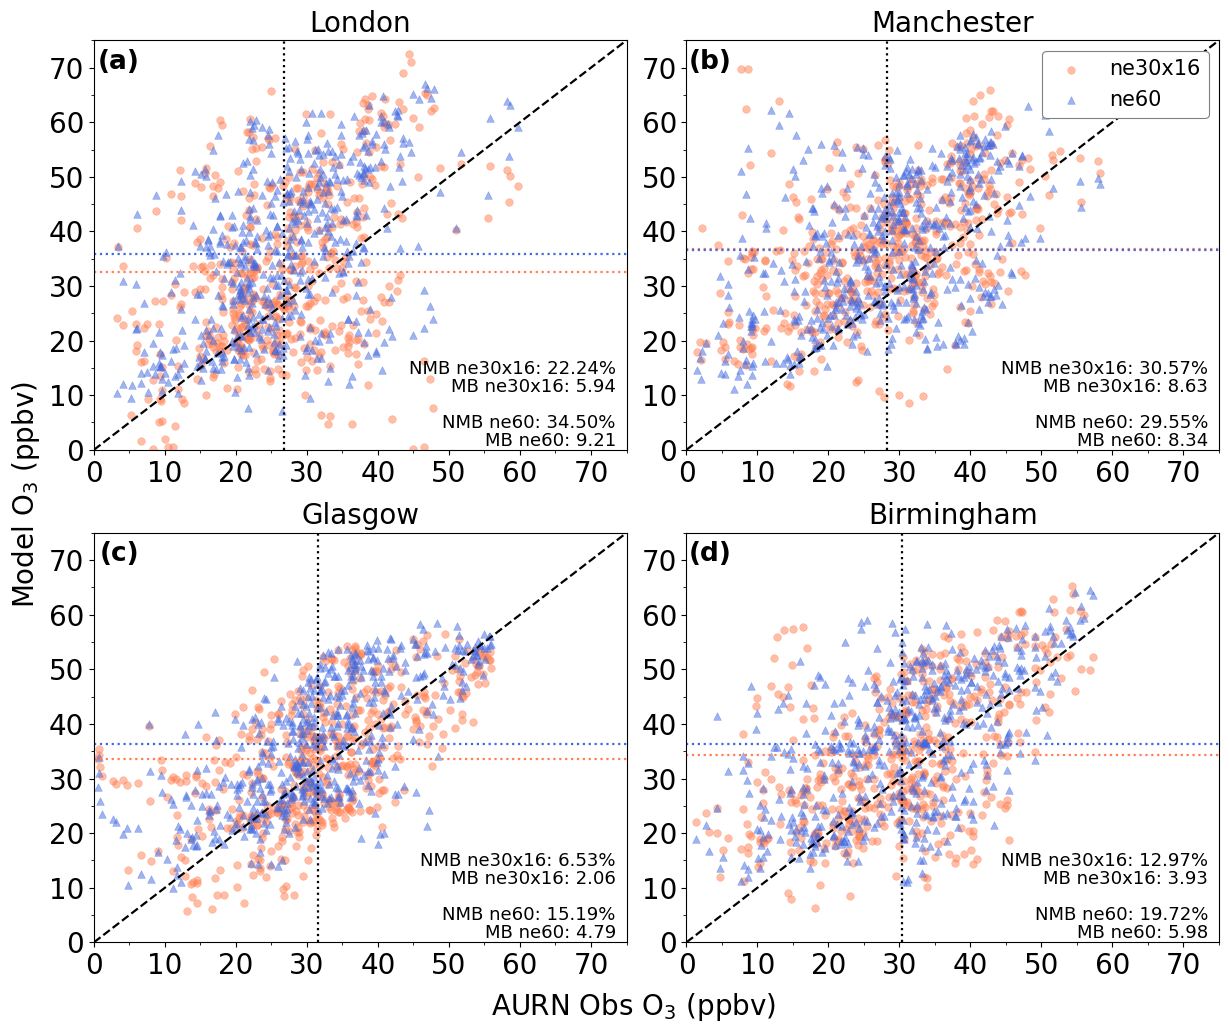

In [19]:
cities = list(city_lonlat.keys())

def nmb(model, obs):
    return 100.0 * (np.nansum(model - obs) / np.nansum(obs))

def mb(model, obs):
    return np.nanmean(model - obs)

def plot_o3_scatter(scatter_data):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    lim_min, lim_max = 0, 75

    for i, city in enumerate(cities):
        ax = axes[i]
        dfm = scatter_data[city]

        x_obs = dfm['obs_ppbv'].values
        y_30 = dfm['model30'].values
        y_60 = dfm['model60'].values

        ax.plot([lim_min, lim_max], [lim_min, lim_max], '--', linewidth=1.6, color='k')

        obs_mean = np.nanmean(x_obs)
        mod30_mean = np.nanmean(y_30)
        mod60_mean = np.nanmean(y_60)

        ax.axvline(obs_mean, linestyle=':', linewidth=1.6, color='k')
        ax.axhline(mod30_mean, linestyle=':', linewidth=1.6, color='coral')
        ax.axhline(mod60_mean, linestyle=':', linewidth=1.6, color='royalblue')

        ax.scatter(x_obs, y_30, s=30, alpha=0.5,
                   label='ne30x16', linewidth=0.4, color='coral')
        ax.scatter(x_obs, y_60, s=30, alpha=0.5,
                   label='ne60', marker='^', linewidth=0.4, color='royalblue')

        ax.set_xlim(lim_min, lim_max)
        ax.set_ylim(lim_min, lim_max)
        ax.set_title(city, fontsize=20)
        ax.grid(alpha=0.3)
        ax.yaxis.set_major_locator(MultipleLocator(10))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))


        mb30 = mb(y_30, x_obs)
        mb60 = mb(y_60, x_obs)
        nmb30 = nmb(y_30, x_obs)
        nmb60 = nmb(y_60, x_obs)

        stats_txt = (
            f'NMB ne30x16: {nmb30:.2f}%\n'
            f'MB ne30x16: {mb30:.2f}\n\n'
            f'NMB ne60: {nmb60:.2f}%\n'
            f'MB ne60: {mb60:.2f}\n'
        )

        ax.text(
            0.98, 0.22, stats_txt,
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=13,
            linespacing=1,
        )
        ax.grid(False)
        if i == 1:
            leg = ax.legend(fontsize=15, loc='upper right', frameon=True)
            frame = leg.get_frame()
            frame.set_facecolor('white')
            frame.set_edgecolor('gray')
            frame.set_linewidth(0.8)
            frame.set_alpha(1.0)

        ax.tick_params(axis='both', labelsize=20)

    fig.text(0.5, -0.02, 'AURN Obs O$_3$ (ppbv)', ha='center', fontsize=20)
    fig.text(-0.02, 0.5, 'Model O$_3$ (ppbv)', va='center', rotation='vertical', fontsize=20)

    labels = ['(a)', '(b)', '(c)', '(d)']
    for ax, label in zip(axes, labels):
        ax.text(
            0.085, 0.98,
            label,
            transform=ax.transAxes,
            fontsize=19,
            fontweight='bold',
            va='top', ha='right',
        )
    plt.tight_layout()
    return fig, axes
fig, axes = plot_o3_scatter(scatter_frames)

In [4]:
figure_data_dir = BASE_DIR / 'figure_data'
figure_data_dir.mkdir(parents=True, exist_ok=True)
figure_s5_path = figure_data_dir / 'FigureS5.nc'

max_samples = max(len(df) for df in scatter_frames.values())
city_names = np.asarray(cities, dtype=str)
sample_index = np.arange(max_samples)

scatter_date = np.full((len(cities), max_samples), np.datetime64('NaT'), dtype='datetime64[ns]')
scatter_obs = np.full((len(cities), max_samples), np.nan, dtype=float)
scatter_model30 = np.full((len(cities), max_samples), np.nan, dtype=float)
scatter_model60 = np.full((len(cities), max_samples), np.nan, dtype=float)

for city_idx, city in enumerate(cities):
    df = scatter_frames[city]
    n = len(df)
    scatter_date[city_idx, :n] = df['Date'].to_numpy(dtype='datetime64[ns]')
    scatter_obs[city_idx, :n] = df['obs_ppbv'].to_numpy(dtype=float)
    scatter_model30[city_idx, :n] = df['model30'].to_numpy(dtype=float)
    scatter_model60[city_idx, :n] = df['model60'].to_numpy(dtype=float)

FigureS5 = xr.Dataset(
    data_vars={
        'date': (('city', 'sample'), scatter_date),
        'obs_o3': (('city', 'sample'), scatter_obs),
        'model_o3_ne30x16': (('city', 'sample'), scatter_model30),
        'model_o3_ne60': (('city', 'sample'), scatter_model60),
    },
    coords={
        'city': city_names,
        'sample': sample_index,
    },
)

FigureS5.to_netcdf(figure_s5_path)
FigureS5.close()
print(figure_s5_path)

/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS5.nc


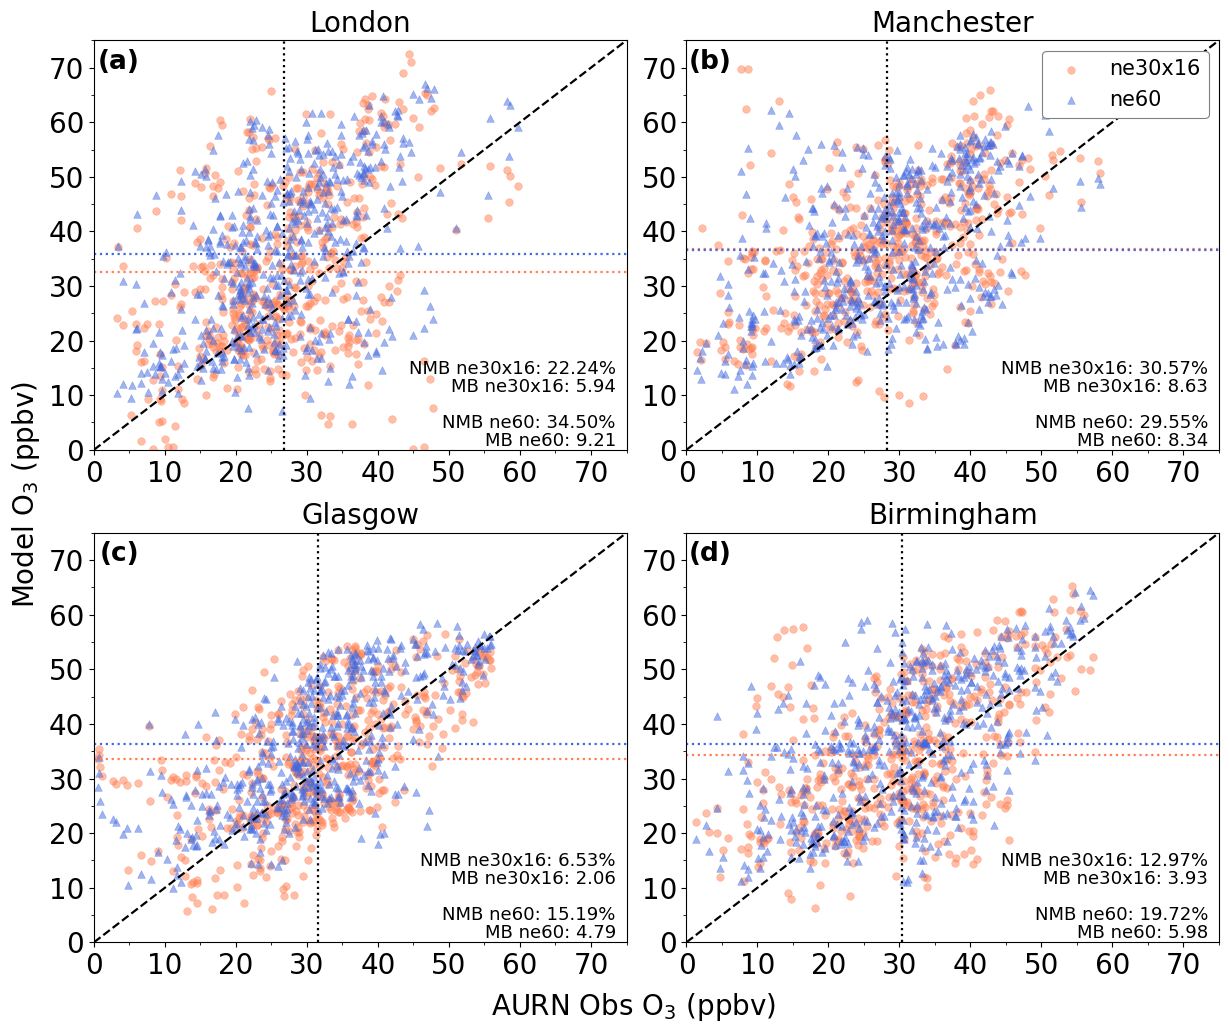

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

BASE_DIR = Path('/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision')
figure_s5_path = BASE_DIR / 'figure_data' / 'FigureS5.nc'
FigureS5_saved = xr.open_dataset(figure_s5_path)

cities = [str(city) for city in FigureS5_saved['city'].values]


def nmb(model, obs):
    return 100.0 * (np.nansum(model - obs) / np.nansum(obs))


def mb(model, obs):
    return np.nanmean(model - obs)


def _saved_city_data(city):
    saved_city = FigureS5_saved.sel(city=city)
    df = pd.DataFrame({
        'Date': pd.to_datetime(saved_city['date'].values),
        'obs_ppbv': saved_city['obs_o3'].values,
        'model30': saved_city['model_o3_ne30x16'].values,
        'model60': saved_city['model_o3_ne60'].values,
    })
    return df.replace([np.inf, -np.inf], np.nan).dropna()


def plot_o3_scatter_from_saved():
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    lim_min, lim_max = 0, 75

    for i, city in enumerate(cities):
        ax = axes[i]
        dfm = _saved_city_data(city)

        x_obs = dfm['obs_ppbv'].values
        y_30 = dfm['model30'].values
        y_60 = dfm['model60'].values

        ax.plot([lim_min, lim_max], [lim_min, lim_max], '--', linewidth=1.6, color='k')

        obs_mean = np.nanmean(x_obs)
        mod30_mean = np.nanmean(y_30)
        mod60_mean = np.nanmean(y_60)

        ax.axvline(obs_mean, linestyle=':', linewidth=1.6, color='k')
        ax.axhline(mod30_mean, linestyle=':', linewidth=1.6, color='coral')
        ax.axhline(mod60_mean, linestyle=':', linewidth=1.6, color='royalblue')

        ax.scatter(x_obs, y_30, s=30, alpha=0.5,
                   label='ne30x16', linewidth=0.4, color='coral')
        ax.scatter(x_obs, y_60, s=30, alpha=0.5,
                   label='ne60', marker='^', linewidth=0.4, color='royalblue')

        ax.set_xlim(lim_min, lim_max)
        ax.set_ylim(lim_min, lim_max)
        ax.set_title(city, fontsize=20)
        ax.grid(alpha=0.3)
        ax.yaxis.set_major_locator(MultipleLocator(10))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))


        mb30 = mb(y_30, x_obs)
        mb60 = mb(y_60, x_obs)
        nmb30 = nmb(y_30, x_obs)
        nmb60 = nmb(y_60, x_obs)

        stats_txt = (
            f'NMB ne30x16: {nmb30:.2f}%\n'
            f'MB ne30x16: {mb30:.2f}\n\n'
            f'NMB ne60: {nmb60:.2f}%\n'
            f'MB ne60: {mb60:.2f}\n'
        )

        ax.text(
            0.98, 0.22, stats_txt,
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=13,
            linespacing=1,
        )
        ax.grid(False)
        if i == 1:
            leg = ax.legend(fontsize=15, loc='upper right', frameon=True)
            frame = leg.get_frame()
            frame.set_facecolor('white')
            frame.set_edgecolor('gray')
            frame.set_linewidth(0.8)
            frame.set_alpha(1.0)

        ax.tick_params(axis='both', labelsize=20)

    fig.text(0.5, -0.02, 'AURN Obs O$_3$ (ppbv)', ha='center', fontsize=20)
    fig.text(-0.02, 0.5, 'Model O$_3$ (ppbv)', va='center', rotation='vertical', fontsize=20)

    labels = ['(a)', '(b)', '(c)', '(d)']
    for ax, label in zip(axes, labels):
        ax.text(
            0.085, 0.98,
            label,
            transform=ax.transAxes,
            fontsize=19,
            fontweight='bold',
            va='top', ha='right',
        )

    plt.tight_layout()
    return fig, axes
fig, axes = plot_o3_scatter_from_saved()



# FIGURES_DIR = BASE_DIR / 'figures' / 'SI'
# FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# RASTER_DPI = 300
# png_path = FIGURES_DIR / 'FigureS5.png'
# pdf_path = FIGURES_DIR / 'FigureS5.pdf'

# fig.savefig(png_path, dpi=RASTER_DPI, bbox_inches='tight', facecolor='white')

# img = plt.imread(png_path)
# height_px, width_px = img.shape[:2]
# pdf_fig = plt.figure(figsize=(width_px / RASTER_DPI, height_px / RASTER_DPI), dpi=RASTER_DPI)
# pdf_ax = pdf_fig.add_axes([0, 0, 1, 1])
# pdf_ax.imshow(img)
# pdf_ax.axis('off')
# pdf_fig.savefig(pdf_path, format='pdf', dpi=RASTER_DPI, bbox_inches=None, pad_inches=0, facecolor='white')
# plt.close(pdf_fig)